11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - kl_loss: 2.8879 - loss: 169.0823 - reconstruction_loss: 166.1945
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 2.8861 - loss: 163.1518 - reconstruction_loss: 160.2658
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.3267 - loss: 151.8182 - reconstruction_loss: 148.4914
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.3923 - loss: 153.9393 - reconstruction_loss: 150.5470
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.3358 - loss: 146.1847 - reconstruction_loss: 142.8489
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.4508 - loss: 150.8771 - reconstruction_loss: 147.4263
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.3601 - loss: 149.0464 - reconstruction_loss: 145.6864
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 3.5684 - loss: 145.8860 - reconstruction_loss

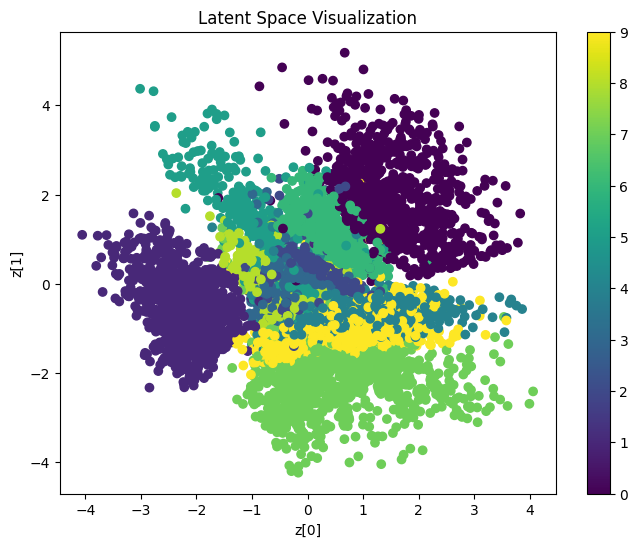

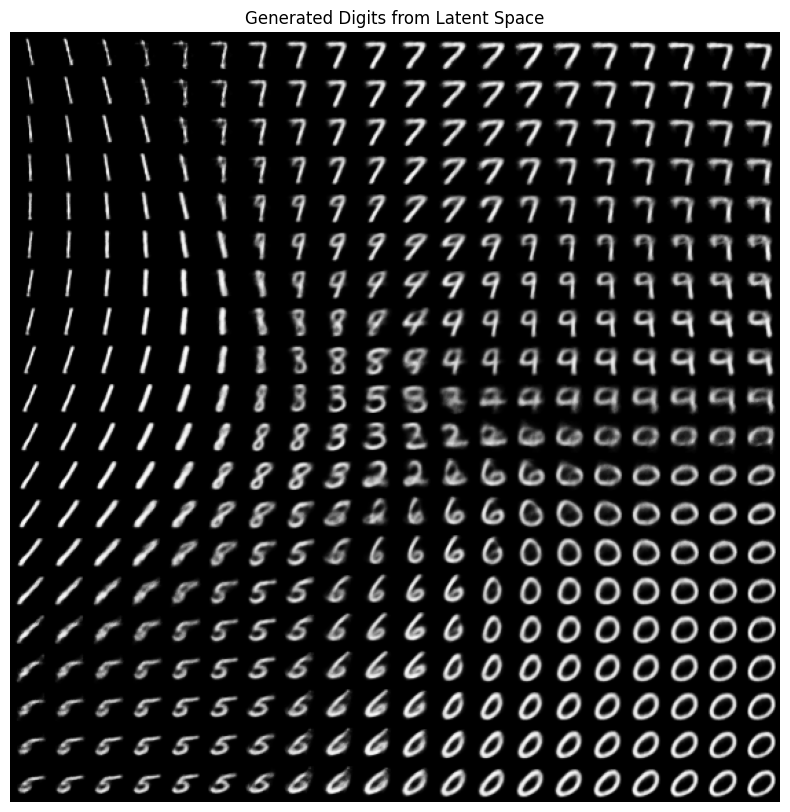

In [ ]:
# =========================================================
# Variational Autoencoder (VAE) - Keras 3 Compatible
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---------------------------------------------------------
# 1. Load MNIST
# ---------------------------------------------------------

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# ---------------------------------------------------------
# 2. Sampling Layer
# ---------------------------------------------------------

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# ---------------------------------------------------------
# 3. Encoder
# ---------------------------------------------------------

latent_dim = 2

encoder_inputs = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# ---------------------------------------------------------
# 4. Decoder
# ---------------------------------------------------------

latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# ---------------------------------------------------------
# 5. VAE Model (FIXED)
# ---------------------------------------------------------

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    # ✅ REQUIRED in Keras 3
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            ) * 784

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

# ---------------------------------------------------------
# 6. Train
# ---------------------------------------------------------

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

vae.fit(x_train, epochs=30, batch_size=128)

# ---------------------------------------------------------
# 7. Visualize Latent Space
# ---------------------------------------------------------

z_mean, _, _ = encoder.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap="viridis")
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Latent Space Visualization")
plt.show()

# ---------------------------------------------------------
# 8. Generate Digits
# ---------------------------------------------------------

n = 20
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i*digit_size:(i+1)*digit_size,
               j*digit_size:(j+1)*digit_size] = digit

plt.figure(figsize=(10,10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Generated Digits from Latent Space")
plt.show()